# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [1]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?


In [3]:
# Class distribution
print("Value counts:")
print(fraud['fraud'].value_counts())

print("\nClass proportions:")
print(fraud['fraud'].value_counts(normalize=True).round(4))

Value counts:
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

Class proportions:
fraud
0.0    0.9126
1.0    0.0874
Name: proportion, dtype: float64


Yes, the target is imbalanced, because the fraud=True is only 8,7%

- **2.** Train a LogisticRegression.


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = fraud.drop(columns='fraud')
y = fraud['fraud']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

print("Training complete!")
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples:     {X_test.shape[0]:,}")


Training complete!
Training samples: 800,000
Test samples:     200,000


- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.


              precision    recall  f1-score   support

  Legitimate       0.96      0.99      0.98    182557
       Fraud       0.89      0.60      0.72     17443

    accuracy                           0.96    200000
   macro avg       0.93      0.80      0.85    200000
weighted avg       0.96      0.96      0.96    200000

ROC-AUC Score: 0.9669


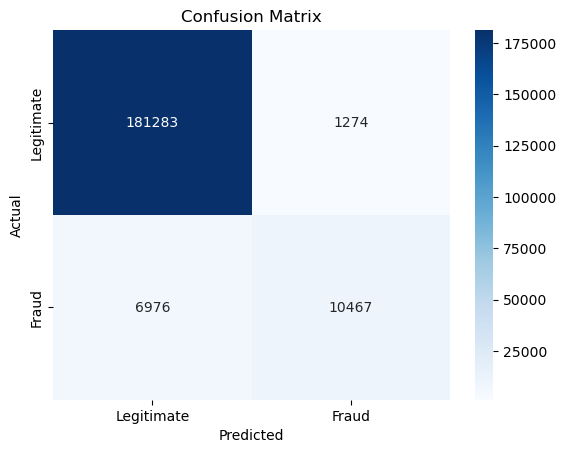

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = lr.predict(X_test_scaled)
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Classification report
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# ROC-AUC
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


Fraud recall is only 60%, meaning the model catches only 60% of fraudulent transactions. 

- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 


In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Applying oversampling on training data ONLY
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

# Checking new class distribution
print("Before oversampling:", y_train.value_counts().to_dict())
print("After oversampling: ", pd.Series(y_train_ros).value_counts().to_dict())

# Training new model
lr_ros = LogisticRegression(random_state=42)
lr_ros.fit(X_train_ros, y_train_ros)

# Evaluation
y_pred_ros = lr_ros.predict(X_test_scaled)
y_pred_ros_proba = lr_ros.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_ros, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_ros_proba):.4f}")


Before oversampling: {0.0: 730040, 1.0: 69960}
After oversampling:  {0.0: 730040, 1.0: 730040}
              precision    recall  f1-score   support

  Legitimate       1.00      0.93      0.96    182557
       Fraud       0.58      0.95      0.72     17443

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000

ROC-AUC Score: 0.9796


Oversampling significantly improved fraud **recall** from 60% to 95% — the model now catches 95% of fraudulent transactions.  
However, this came at the cost of **precision**, which dropped from 89% to 58%, meaning more false alarms on legitimate transactions.  
The F1-score remained same and ROC-AUC improved slightly (to 0.9796), indicating better overall ranking ability.

**Verdict:** Oversampling is a good choice when catching fraud is the top priority and false alarms are an acceptable tradeoff.

- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Applying undersampling on training data ONLY
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

# Checking new class distribution
print("Before undersampling:", y_train.value_counts().to_dict())
print("After undersampling: ", pd.Series(y_train_rus).value_counts().to_dict())

# Training new model
lr_rus = LogisticRegression(random_state=42)
lr_rus.fit(X_train_rus, y_train_rus)

# Evaluation
y_pred_rus = lr_rus.predict(X_test_scaled)
y_pred_rus_proba = lr_rus.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rus, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_rus_proba):.4f}")


Before undersampling: {0.0: 730040, 1.0: 69960}
After undersampling:  {0.0: 69960, 1.0: 69960}
              precision    recall  f1-score   support

  Legitimate       1.00      0.93      0.96    182557
       Fraud       0.58      0.95      0.72     17443

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000

ROC-AUC Score: 0.9795


Undersampling produced identical results to oversampling (recall 95%, precision 58%, F1 72%, ROC-AUC 0.9795), but at the cost of discarding 90% of the majority class training data (~660k rows). 

**Verdict:** Same performance as oversampling but wastes real data — the weakest of the three resampling approaches.

- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

In [ ]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE on training data ONLY
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Checking new class distribution
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_smote).value_counts().to_dict())

# Training new model
lr_smote = LogisticRegression(random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

# Evaluation
y_pred_smote = lr_smote.predict(X_test_scaled)
y_pred_smote_proba = lr_smote.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_smote, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_smote_proba):.4f}")

Before SMOTE: {0.0: 730040, 1.0: 69960}
After SMOTE:  {0.0: 730040, 1.0: 730040}
              precision    recall  f1-score   support

  Legitimate       1.00      0.93      0.96    182557
       Fraud       0.58      0.95      0.72     17443

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000

ROC-AUC Score: 0.9796


SMOTE produced identical results to both oversampling and undersampling (recall 95%, precision 58%, F1 72%, ROC-AUC 0.9796). Despite generating synthetic fraud examples rather than simply copying or deleting rows, the results were no different.

All three resampling techniques improved fraud recall dramatically compared to the baseline, but produced virtually identical results to each other.
To improve further, the next step would be to try a more powerful model.